# RAG Baseline Results

Evaluation of the baseline RAG system on the QA task from RAGTruth dataset.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from rouge_score import rouge_scorer
from collections import Counter

## Load Results

In [2]:
def load_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            records.append(json.loads(line))
    return records

results = load_jsonl("../baselines/rag_baseline_answers.jsonl")
print(f"Total QA pairs evaluated: {len(results)}")

Total QA pairs evaluated: 100


## ROUGE Scores

In [3]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

rouge1_scores = []
rouge2_scores = []
rougeL_scores = []

for r in results:
    scores = scorer.score(r['gold_answer'], r['generated_answer'])
    rouge1_scores.append(scores['rouge1'].fmeasure)
    rouge2_scores.append(scores['rouge2'].fmeasure)
    rougeL_scores.append(scores['rougeL'].fmeasure)

avg_rouge1 = sum(rouge1_scores) / len(rouge1_scores)
avg_rouge2 = sum(rouge2_scores) / len(rouge2_scores)
avg_rougeL = sum(rougeL_scores) / len(rougeL_scores)

print(f"ROUGE-1: {avg_rouge1:.4f}")
print(f"ROUGE-2: {avg_rouge2:.4f}")
print(f"ROUGE-L: {avg_rougeL:.4f}")

ROUGE-1: 0.0662
ROUGE-2: 0.0401
ROUGE-L: 0.0624


## ROUGE Score Distribution

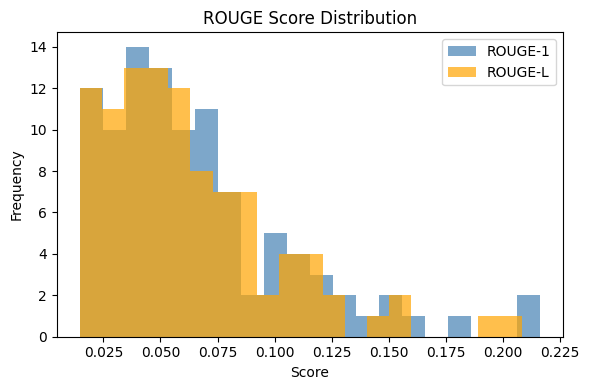

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(rouge1_scores, bins=20, alpha=0.7, label='ROUGE-1', color='steelblue')
ax.hist(rougeL_scores, bins=20, alpha=0.7, label='ROUGE-L', color='orange')
ax.set_xlabel('Score')
ax.set_ylabel('Frequency')
ax.set_title('ROUGE Score Distribution')
ax.legend()
plt.tight_layout()
plt.show()

## Answer Quality Categories

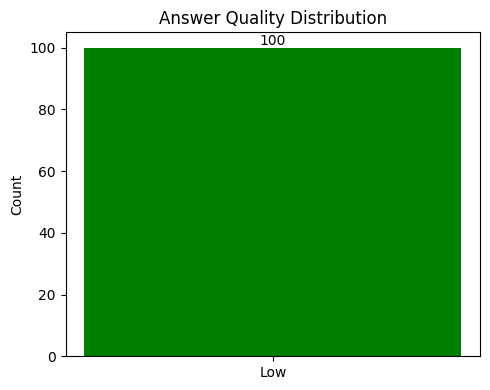

High quality: 0 (0.0%)
Medium quality: 0 (0.0%)
Low quality: 100 (100.0%)


In [5]:
def categorize_quality(rouge1):
    if rouge1 >= 0.6:
        return 'High'
    elif rouge1 >= 0.3:
        return 'Medium'
    else:
        return 'Low'

categories = [categorize_quality(s) for s in rouge1_scores]
category_counts = Counter(categories)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(category_counts.keys(), category_counts.values(), color=['green', 'orange', 'red'])
ax.set_ylabel('Count')
ax.set_title('Answer Quality Distribution')
for i, (k, v) in enumerate(category_counts.items()):
    ax.text(i, v + 1, str(v), ha='center')
plt.tight_layout()
plt.show()

print(f"High quality: {category_counts['High']} ({category_counts['High']/len(results)*100:.1f}%)")
print(f"Medium quality: {category_counts['Medium']} ({category_counts['Medium']/len(results)*100:.1f}%)")
print(f"Low quality: {category_counts['Low']} ({category_counts['Low']/len(results)*100:.1f}%)")

## Sample Outputs

In [6]:
high_quality = [(r, s) for r, s in zip(results, rouge1_scores) if s >= 0.6]
low_quality = [(r, s) for r, s in zip(results, rouge1_scores) if s < 0.3]

print("=== High Quality Example ===")
if high_quality:
    r, s = high_quality[0]
    print(f"Question: {r['question']}")
    print(f"Gold: {r['gold_answer'][:200]}...")
    print(f"Generated: {r['generated_answer'][:200]}...")
    print(f"ROUGE-1: {s:.4f}")

print("\n=== Low Quality Example ===")
if low_quality:
    r, s = low_quality[0]
    print(f"Question: {r['question']}")
    print(f"Gold: {r['gold_answer'][:200]}...")
    print(f"Generated: {r['generated_answer'][:200]}...")
    print(f"ROUGE-1: {s:.4f}")

=== High Quality Example ===

=== Low Quality Example ===
Question: how do automotive technicians get paid
Gold: Automotive technicians can be paid in various ways depending on factors such as where they work, whether they are paid commission, how much they earn, and the state in which they work. Some may be ent...
Generated: I cannot answer based on the given passages....
ROUGE-1: 0.0476
